## Importing Libraries
- NumPy and Pandas are used for numerical operations and data manipulation.
- Matplotlib and Seaborn are used for visualization.
- sklearn provides tools for machine learning, including datasets, model selection, and evaluation metrics.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

## Load the Data
- The Diabetes dataset contains various health measurements of patients, with the target variable indicating the presence or absence of diabetes.

- Load the Diabetes dataset from sklearn

In [2]:
diabetes = datasets.load_diabetes()
X = diabetes.data  # Features
y = (diabetes.target > 140).astype(int)  # Binary target: 1 if diabetes, 0 otherwise

# Create a DataFrame for better visualization
diabetes_df = pd.DataFrame(data=X, columns=diabetes.feature_names)
diabetes_df['diabetes'] = y
diabetes_df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,diabetes
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,1
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,1
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,1
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,0


## Data Visualization
- The pairplot function from Seaborn creates scatter plots for each pair of features, colored by the diabetes status. This helps visualize the separability of classes.

- Visualize the data

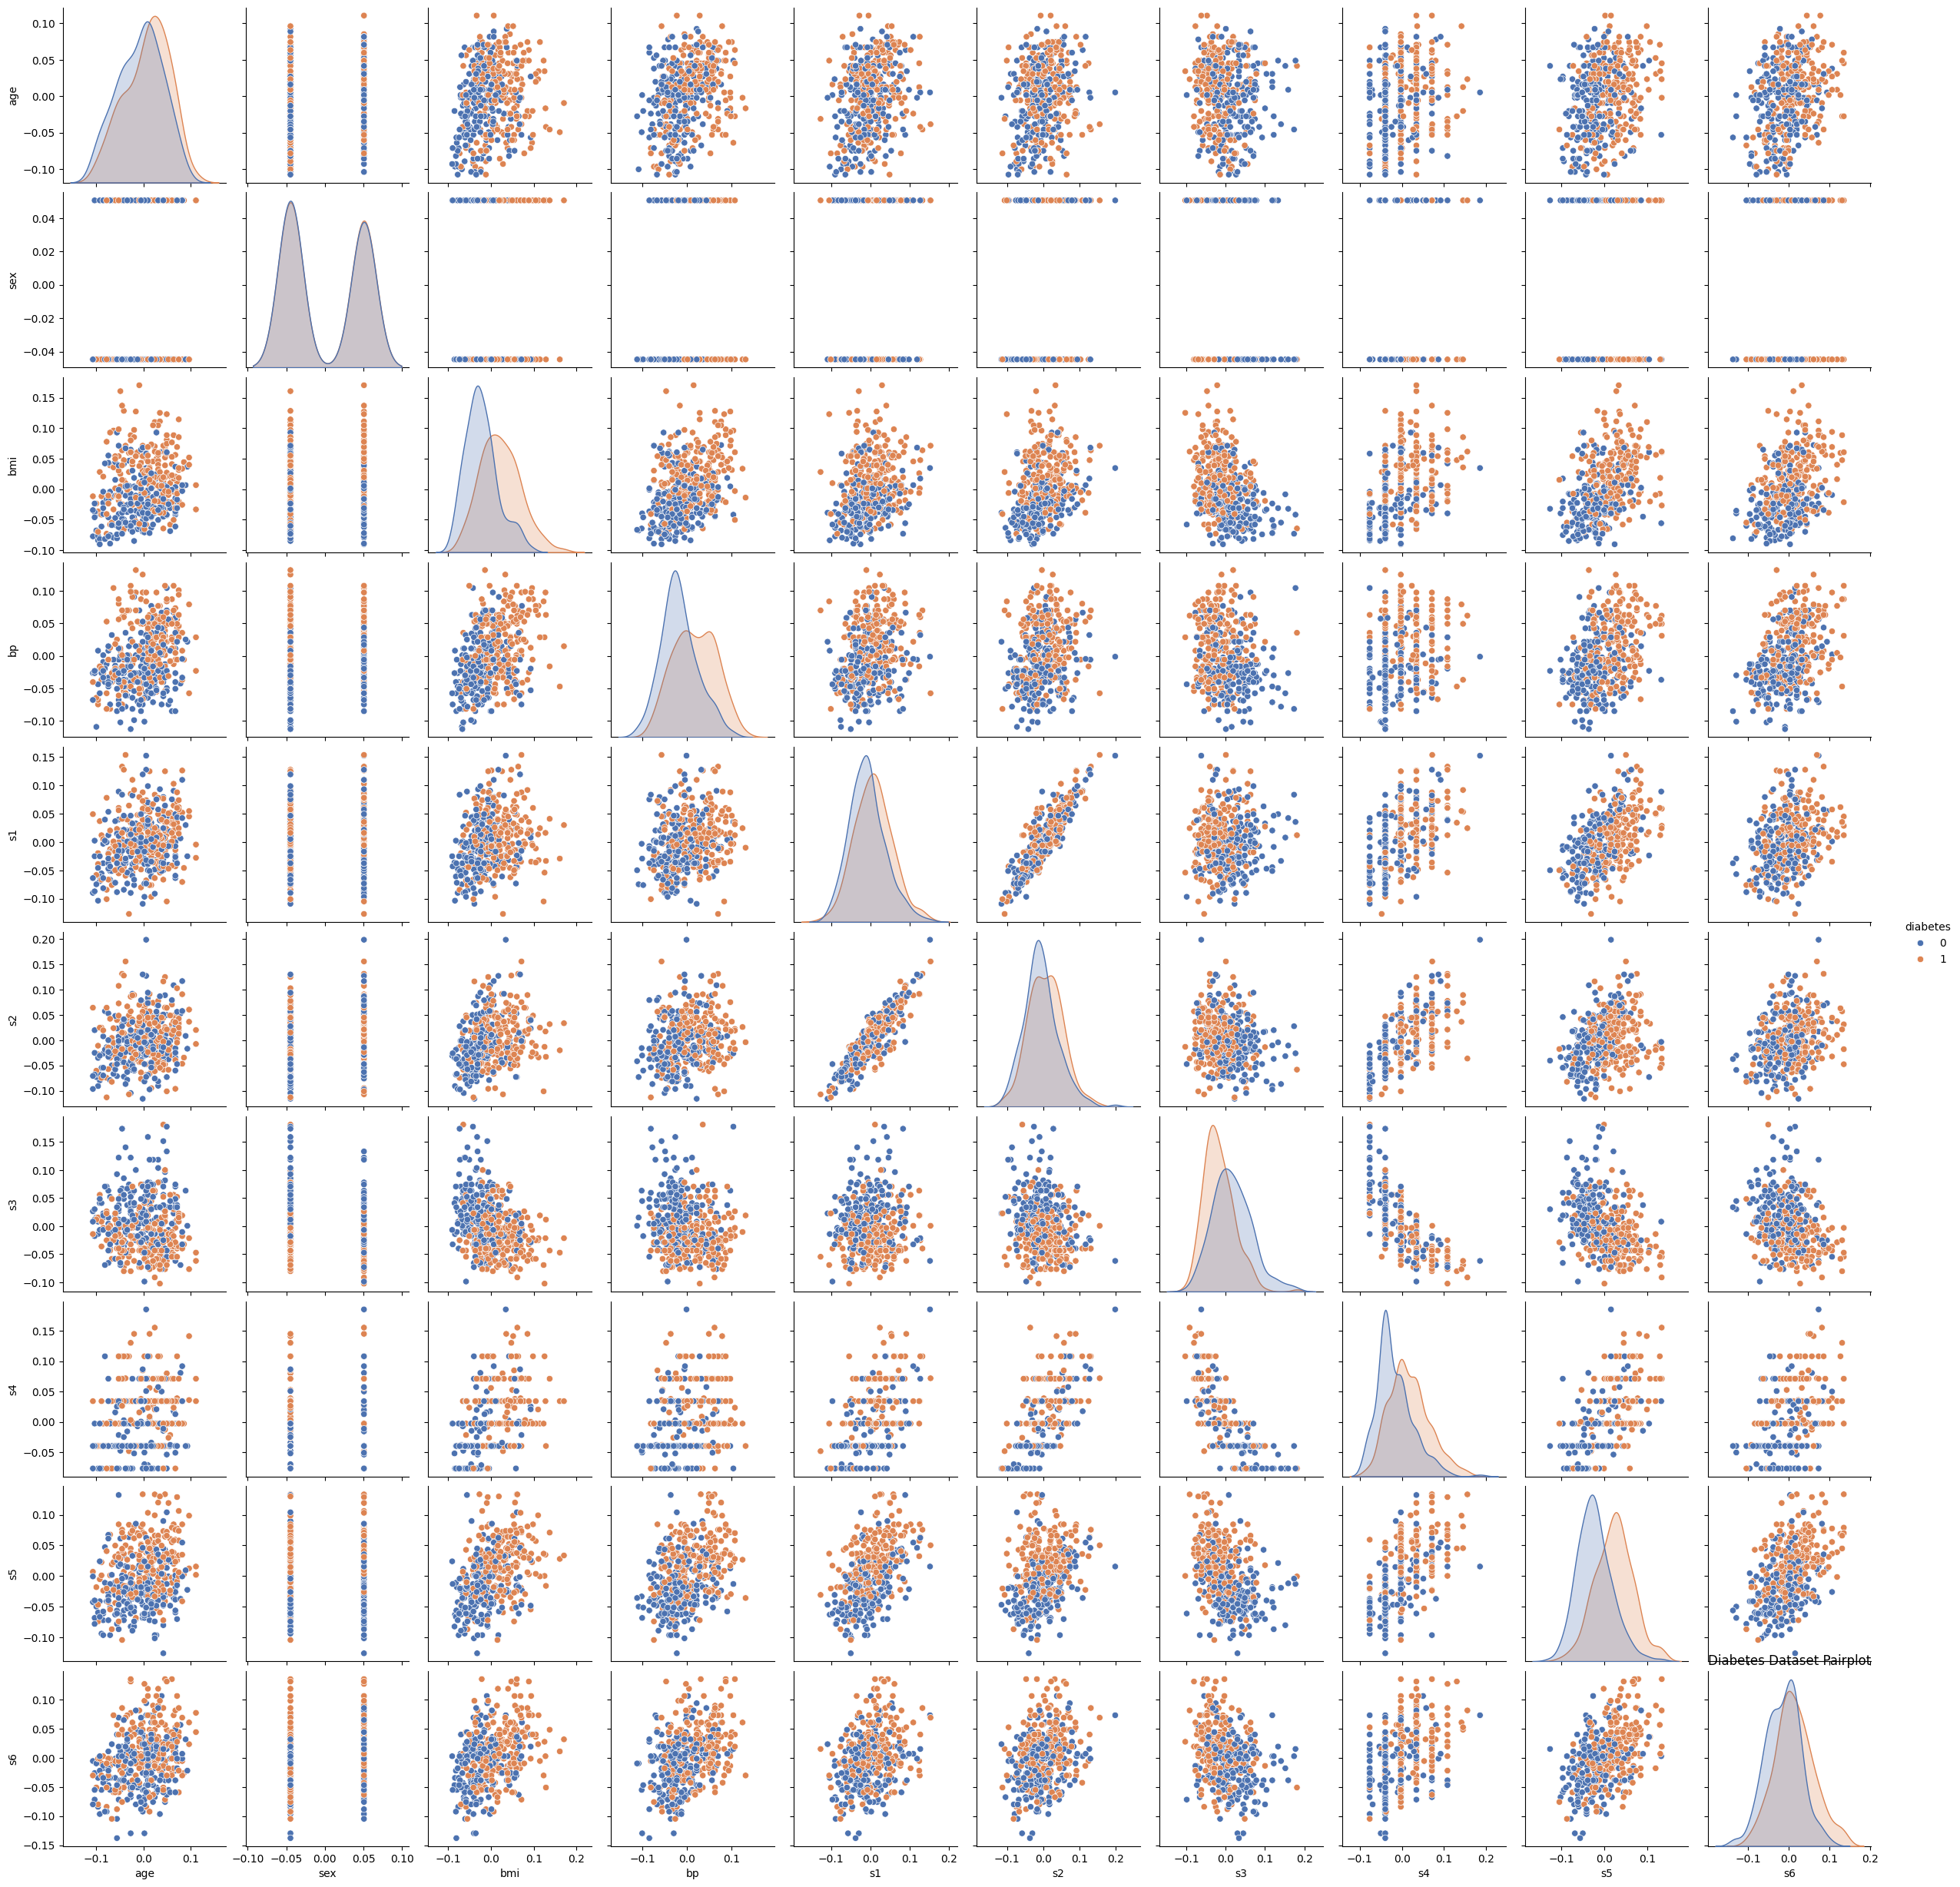

In [3]:
sns.pairplot(diabetes_df, hue='diabetes', palette='deep')
plt.title("Diabetes Dataset Pairplot")
plt.show()

## Split the Data
- The train_test_split function splits the dataset into training (80%) and testing (20%) subsets, ensuring that our model can be evaluated on unseen data.

- Split the data into training and testing sets

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Train the Random Forest Model
- Here, we create an instance of the Random Forest classifier and fit it to the training data. Random Forest is an ensemble method that combines multiple decision trees to improve accuracy and control overfitting.

- Create a Random Forest classifier

In [5]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Make Predictions
- The predict method generates predictions for the test data based on the model trained in the previous step.

In [6]:
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

## Evaluate the Model
- The confusion matrix shows the number of true vs. predicted classifications, allowing us to see where the model makes mistakes. The classification report includes precision, recall, and F1-score, providing a comprehensive view of the model's performance.

- Evaluate the model on training data

In [7]:
print("Confusion Matrix: Train Data")
print(confusion_matrix(y_train, y_train_pred))
print("\nClassification Report:")
print(classification_report(y_train, y_train_pred))
print("============================================================================")

# Evaluate the model on test data
print("Confusion Matrix: Test Data")
print(confusion_matrix(y_test, y_test_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

Confusion Matrix: Train Data
[[172   0]
 [  0 181]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       172
           1       1.00      1.00      1.00       181

    accuracy                           1.00       353
   macro avg       1.00      1.00      1.00       353
weighted avg       1.00      1.00      1.00       353

Confusion Matrix: Test Data
[[37 12]
 [13 27]]

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.76      0.75        49
           1       0.69      0.68      0.68        40

    accuracy                           0.72        89
   macro avg       0.72      0.72      0.72        89
weighted avg       0.72      0.72      0.72        89



## Feature Importance
- Random Forest provides insights into feature importance, indicating which features contribute most to the model's predictions.

- Plot feature importances

Feature ranking:
bmi: 0.2081
s5: 0.1604
bp: 0.1187
s2: 0.0929
s3: 0.0913
s6: 0.0843
s1: 0.0797
age: 0.0783
s4: 0.0661
sex: 0.0202


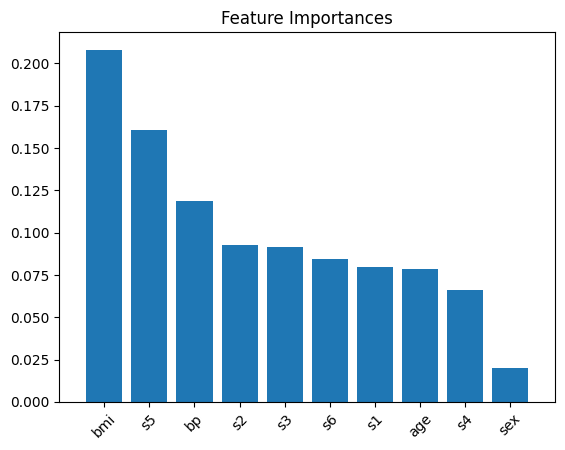

In [8]:
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Print feature ranking
print("Feature ranking:")
for f in range(X.shape[1]):
    print(f"{diabetes.feature_names[indices[f]]}: {importances[indices[f]]:.4f}")

# Plot the feature importances
plt.figure()
plt.title("Feature Importances")
plt.bar(range(X.shape[1]), importances[indices], align='center')
plt.xticks(range(X.shape[1]), np.array(diabetes.feature_names)[indices], rotation=45)
plt.xlim([-1, X.shape[1]])
plt.show()